# Scores and aggregation

Two deliverables.

1. **Figures**: precision, recall and F1 maps, units ranked by decreasing relative uncertainty,
   the national summary, and the propagation to a corrected quantity.
2. **The calibration table**: one row per unit, carrying every number computed here. Everything
   downstream reads it, so this notebook is the single point where the evaluation becomes a set of
   parameters.

Inputs are the two annotation point files. They share a structure but not a semantics: on the
precision side the outcome says whether a detection was real, on the recall side whether a real
installation was found. Keeping that distinction in view avoids a class of confusion later.

All the machinery lives in `helpers.py`, to keep the notebook readable.

## Which uncertainty is which: read this before the rest

Several uncertainty figures coexist here and they are not interchangeable. In the order they stack:

**Precision and recall uncertainty**, each on its own proportion, from the number of annotated
points in that unit. Two distinct campaigns with different sample sizes, so the two are not
comparable to each other. This is the building block.

**F1 uncertainty** combines the two into a single detection-quality score. It answers "how sure am
I of detection quality here?". A model diagnostic, and *not* what gets propagated to a corrected
quantity.

**Correction-factor uncertainty** combines the same two quantities differently, as P/R, the factor
that turns a raw quantity into a corrected one. **This is the number that matters downstream**: how
wrong could the corrected estimate be in this unit? It is the reference throughout this notebook.

**Why the correction factor is more uncertain than either rate alone.** It combines two uncertain
quantities through a ratio, so its relative uncertainty is structurally at least as large as each
of theirs: two error sources compound rather than one being buffered.

This has a practical consequence worth stating, because it has caught people out. Looking at
precision or recall alone suggests around 30% at the worst unit. That figure does not survive the
combination: the true maximum on the correction factor is far wider, near 63% for the most thinly
covered unit. Quoting the per-rate number as if it described the estimate would understate the
uncertainty by half.

**Beta against Wilson** are two ways of computing the interval of *one* proportion, not two
competing results. The Bayesian interval is used everywhere here; the frequentist one appears once,
as an independent check. They agree closely, which is what tells us the Bayesian figures are not an
artefact of the prior. One number per unit, not two.

**Total width against half-width.** The stored uncertainty is the *total* interval width relative
to the mean. The reading used in the paper is the **half-width**, so a unit at 40% total width is
reported as known to ±20%. The half-width column is what appears in the text and figures; the total
width serves the internal computations only. Mixing the two silently doubles or halves every
uncertainty claim.

**Confidence level.** One level, set once in the configuration, used everywhere. No parallel display
of two levels.

## 0. Config

In [1]:
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('src').resolve()))
def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)
sys.path.insert(0, str(_find_root(Path.cwd())))
import paths
import helpers
import style
style.apply(fig_width_in=15)

pd.set_option('display.max_rows', 120)
BASE = Path('.').resolve()
print("Dossier de travail :", BASE)

PRECISION_FILE = Path('precision') / paths.PRECISION_POINTS
RECALL_FILE = Path('recall') / paths.RECALL_POINTS
DEPARTEMENTS_FILE = Path('src') / paths.DEPARTEMENTS
# Shared figures folder, with a per-notebook prefix so the source of each file
# stays identifiable.
FIGS_DIR = paths.FIGURES
FIG_PREFIX = 'eval_detection'
OUTPUT_TABLE = paths.EVAL_TABLE

CI_LEVEL = 0.95   # the only confidence level in this notebook; change it here, nowhere else
EXAMPLE_MW = 1000  # a hypothetical raw quantity for the propagation demo; it cancels out

Dossier de travail : /sessions/happy-gracious-franklin/mnt/Publication/source/code/0_pipeline/evaluation


## 1. Chargement

In [2]:
assert PRECISION_FILE.exists(), f"{PRECISION_FILE} introuvable -- lancer precision/precision.ipynb d'abord"
assert RECALL_FILE.exists(), (
    f"{RECALL_FILE} introuvable -- lancer recall/osm/extract_osm_pbf.py puis recall/recall.ipynb d'abord"
)

precision_points = helpers.load_precision_points(PRECISION_FILE)
recall_points = helpers.load_recall_points(RECALL_FILE)

# Reporting units: Paris and its inner ring merge, pooling their annotation
# samples. Applied uniformly downstream through the calibration table.
import units
precision_points = units.apply_units(precision_points)
recall_points = units.apply_units(recall_points)
print(f"unites : {precision_points['dpt'].nunique()} (mapping {units.DEPT_AGGREGATION})")

print(f"precision_points.csv : {len(precision_points)} lignes, {precision_points['dpt'].nunique()} departements")
print(f"recall_points.csv    : {len(recall_points)} lignes, {recall_points['dpt'].nunique()} departements")

departements = gpd.read_file(DEPARTEMENTS_FILE)
departements = units.dissolve_units(departements) if 'units' in dir() else departements

unites : 93 (mapping {'75': '75PC', '92': '75PC', '93': '75PC', '94': '75PC'})
precision_points.csv : 18023 lignes, 93 departements
recall_points.csv    : 13830 lignes, 93 departements


## Partie 1 -- Visualisations

### 1.1 The per-unit table

The base of everything that follows. One call per building block, all at the configured level.

In [3]:
# Empirical Bayes, applied uniformly to precision AND recall. The correction
# bootstrap and the propagation inherit the choice through the alpha and beta
# columns of the calibration table, which is what keeps the whole chain on one
# prior rather than several. The Jeffreys baseline is in
# 0_data/sanity-checks/sanity_checks.ipynb (comparaison systematique, totaux nationaux invariants).
table = helpers.build_scores_table(precision_points, recall_points, ci=CI_LEVEL, prior='eb')
table = helpers.add_f1_uncertainty(table, ci=CI_LEVEL)
table = helpers.add_capacity_correction_uncertainty(table, ci=CI_LEVEL)

print(f"{table['precision'].notna().sum()} units with precision, "
      f"{table['recall'].notna().sum()} with recall, "
      f"{table['correction_factor_mean'].notna().sum()} with a correction factor")

prior EB precision : Beta(5.6, 1.7) -- mean=0.766, sd_true=0.147, kappa=7
prior EB recall    : Beta(16.0, 10.1) -- mean=0.612, sd_true=0.093, kappa=26


93 units with precision, 93 with recall, 93 with a correction factor


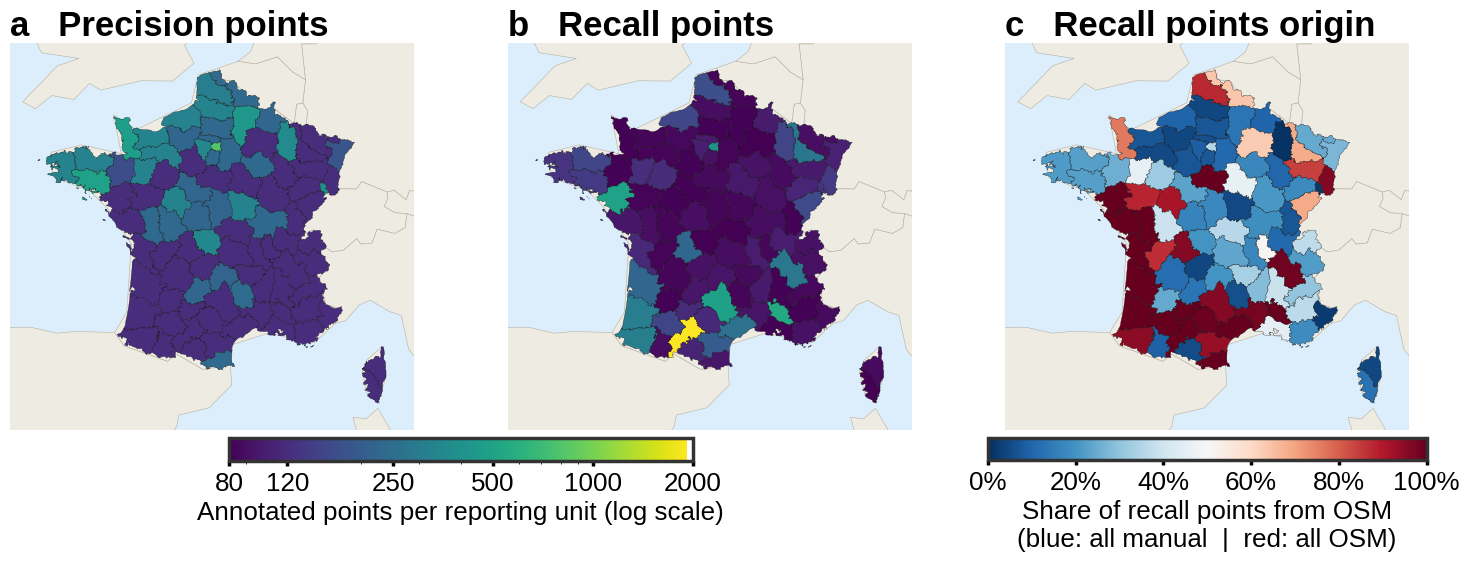

precision  : 18,023 points | min  120 (01) | max  808 (75PC) | mediane 120
rappel     : 13,830 points | min   80 (03) | max 1921 (31) | mediane 92
part OSM   : mediane 26% | national 61% | 13 unites 100% OSM | 0 unites 100% manuelles


In [4]:
# Number of points per departements and source of the points
# number of points for the recall
# agg = recall_points.groupby("dpt").size().reset_index(name="n")
# agg['n'].describe()

# --- Ou porte l'effort d'annotation ------------------------------------------------
# (a) and (b) count annotated points, so they SHARE a scale: that is what makes
#     the gap between the two floors readable.
#     LOG scale, because the median sits at the floor while one unit reaches
#     around 1,900. On a linear scale 90 of 93 units come out white.
# (c) share of recall points sourced from OSM, on a diverging map centred at 50%.
#     Blue is all hand-annotated, red is all OSM. This palette is colour-blind
#     safe, unlike a red-to-green one.
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import NullFormatter, PercentFormatter, ScalarFormatter

style = helpers.style

n_prec = precision_points.groupby('dpt').size().rename('n_precision')
n_rec = recall_points.groupby('dpt').size().rename('n_recall')
share_osm = (recall_points.assign(is_osm=lambda d: d['source'].eq('OSM'))
             .groupby('dpt')['is_osm'].mean().rename('share_osm'))

points_table = pd.concat([n_prec, n_rec, share_osm], axis=1).rename_axis('dpt').reset_index()
dept_pts = departements.merge(points_table, left_on='code', right_on='dpt', how='left')

vmin_n = min(points_table['n_precision'].min(), points_table['n_recall'].min())
vmax_n = max(points_table['n_precision'].max(), points_table['n_recall'].max())
norm_n = LogNorm(vmin=vmin_n, vmax=vmax_n)

panels = [
    ('n_precision', 'a', 'Precision points', style.CMAP_SEQUENTIAL, norm_n),
    ('n_recall', 'b', 'Recall points', style.CMAP_SEQUENTIAL, norm_n),
    ('share_osm', 'c', 'Recall points origin', style.CMAP_DIVERGING, Normalize(0, 1)),
]

fig_effort, axes = plt.subplots(1, 3, figsize=(15, 5.5), layout='constrained')

for ax, (col, letter, name, cmap, norm) in zip(axes, panels):
    helpers.add_basemap(ax, departements.total_bounds)
    dept_pts.plot(column=col, ax=ax, cmap=cmap, norm=norm, legend=False,
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black', linewidth=0.2, zorder=1)
    ax.set_title(f'{letter}   {name}', fontsize=style.FONT_SIZE_PANEL_LABEL,
                 fontweight='bold', loc='left')
    helpers._hide_axis_chrome(ax)

cb_n = fig_effort.colorbar(ScalarMappable(norm=norm_n, cmap=style.CMAP_SEQUENTIAL),
                           ax=list(axes[:2]), orientation='horizontal',
                           fraction=0.06, pad=0.02, shrink=0.6)
cb_n.set_label('Annotated points per reporting unit (log scale)', fontsize=style.FONT_SIZE_SMALL)
cb_n.set_ticks([80, 120, 250, 500, 1000, 2000])
cb_n.ax.xaxis.set_major_formatter(ScalarFormatter())
cb_n.ax.xaxis.set_minor_formatter(NullFormatter())
cb_n.ax.tick_params(labelsize=style.FONT_SIZE_SMALL)

cb_s = fig_effort.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap=style.CMAP_DIVERGING),
                           ax=axes[2], orientation='horizontal',
                           fraction=0.06, pad=0.02, shrink=0.9)
cb_s.set_label('Share of recall points from OSM\n(blue: all manual  |  red: all OSM)',
               fontsize=style.FONT_SIZE_SMALL)
cb_s.ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
cb_s.ax.tick_params(labelsize=style.FONT_SIZE_SMALL)

helpers.save_fig(fig_effort, f'{FIG_PREFIX}_annotation_effort_maps.pdf', FIGS_DIR)
plt.show()

for col, name in [('n_precision', 'precision'), ('n_recall', 'rappel')]:
    s = points_table[col]
    print(f"{name:<10} : {int(s.sum()):>6,} points | min {int(s.min()):>4} "
          f"({points_table.loc[s.idxmin(), 'dpt']}) | max {int(s.max()):>4} "
          f"({points_table.loc[s.idxmax(), 'dpt']}) | mediane {s.median():.0f}")

so = points_table['share_osm']
print(f"part OSM   : mediane {so.median():.0%} | national "
      f"{recall_points['source'].eq('OSM').mean():.0%} | "
      f"{int((so == 1).sum())} unites 100% OSM | {int((so == 0).sum())} unites 100% manuelles")


### 1.2 Precision, recall and F1 maps

Either as three panels side by side, or one figure per metric for separate export.

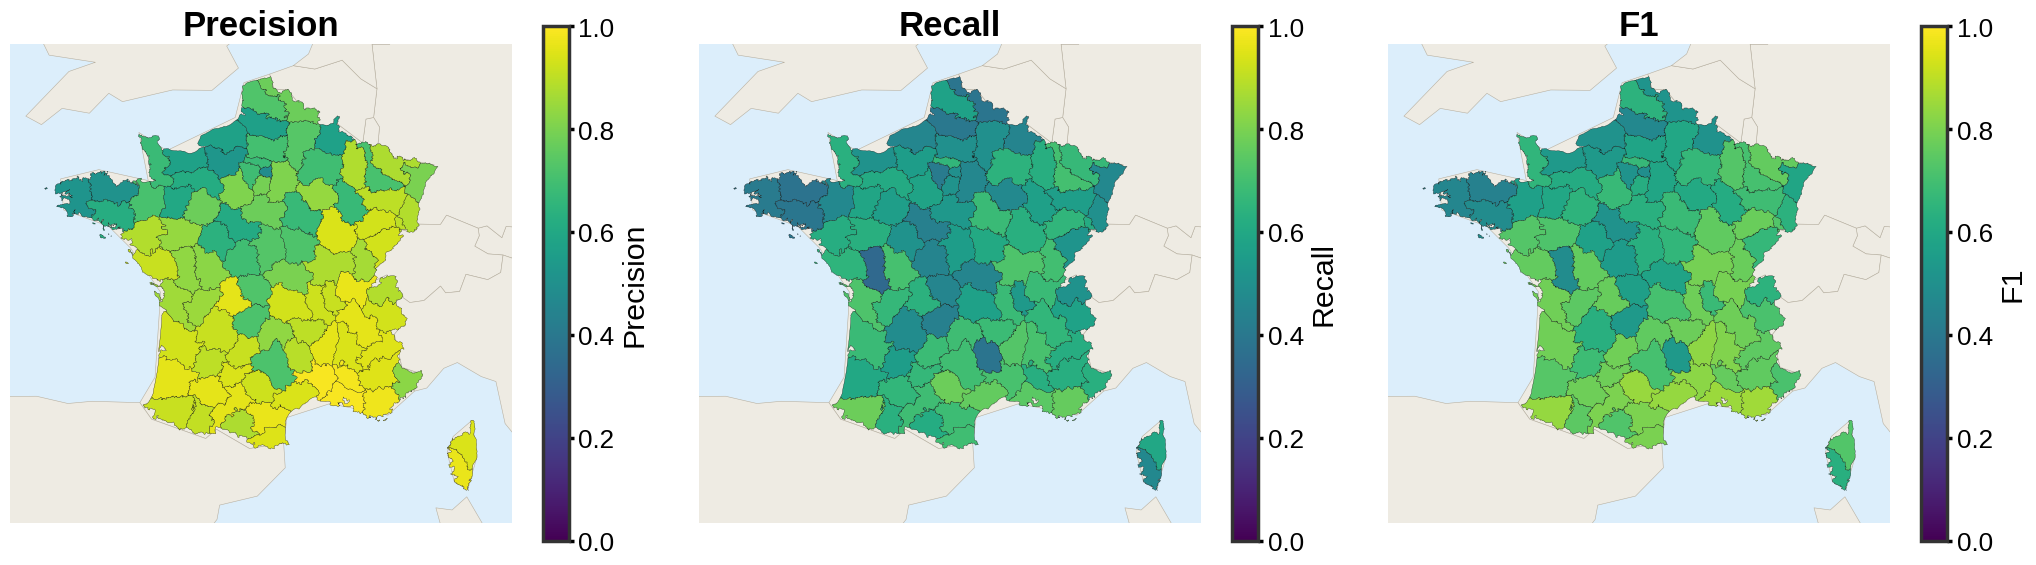

In [5]:
fig_all = helpers.plot_score_maps(departements, table, metrics=('precision', 'recall', 'f1'), mode='all')
helpers.save_fig(fig_all, f'{FIG_PREFIX}_scores_maps_all.pdf', FIGS_DIR)
plt.show()

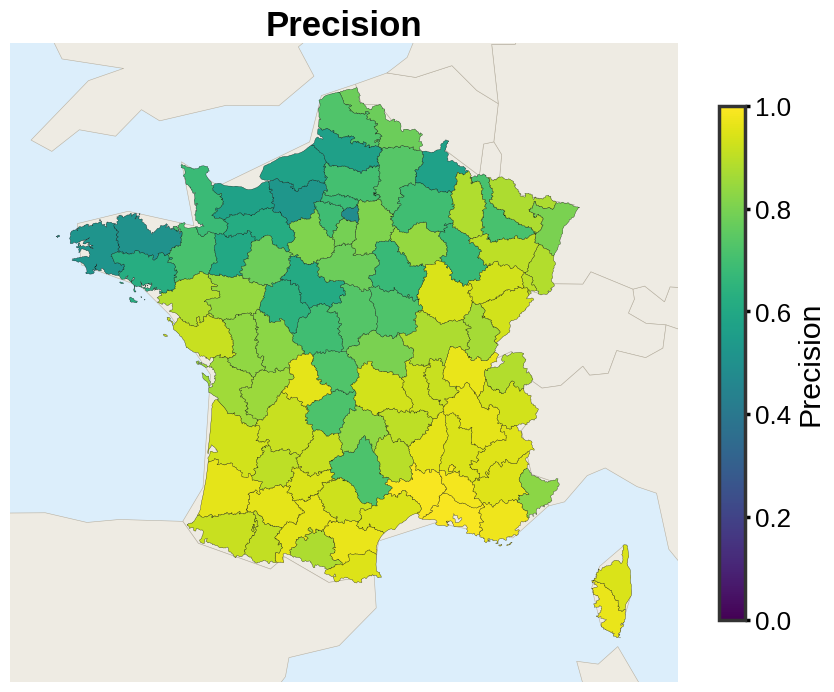

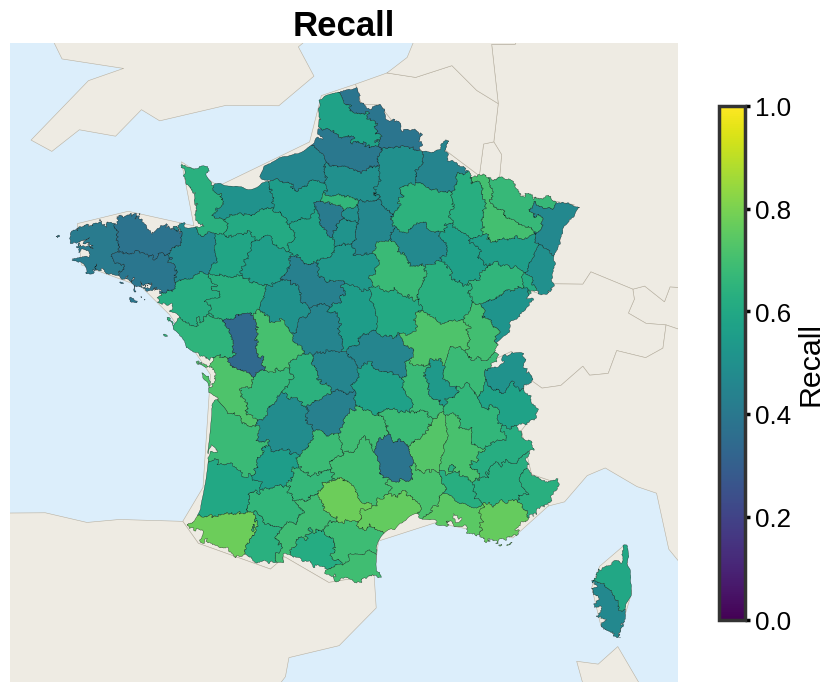

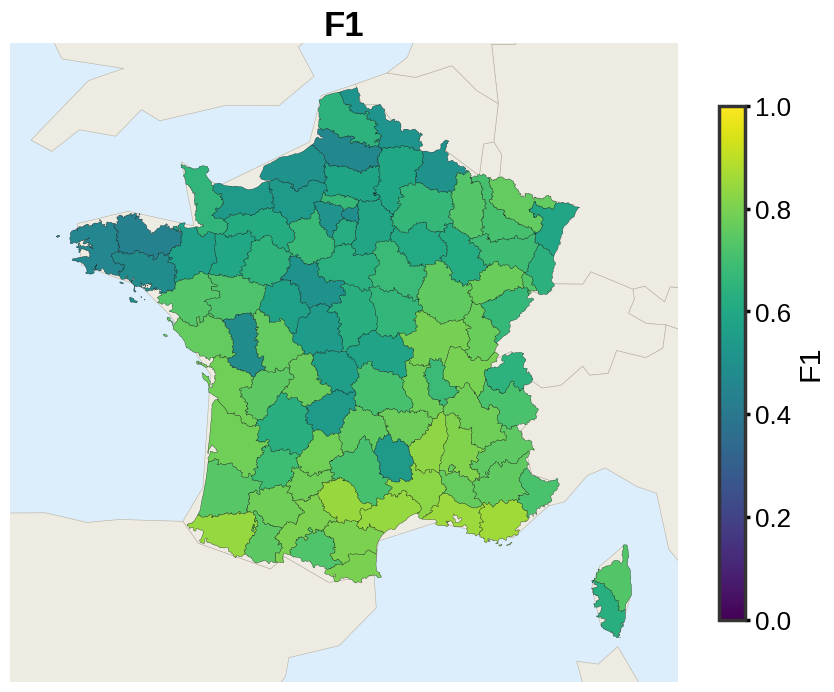

In [6]:
for fig in helpers.plot_score_maps(departements, table, metrics=('precision', 'recall', 'f1'), mode='solo'):
    metric = fig.axes[0].get_title().lower()
    helpers.save_fig(fig, f'{FIG_PREFIX}_score_map_{metric}.png', FIGS_DIR)
    plt.show()

### 1.3 Detector quality buys estimate precision

The map shows the correction factor's uncertainty, the one that matters downstream. The scatter of
F1 against the half-width carries an operational message that is easy to miss: **the better the
detector performs locally, the more precise the corrected capacity estimate**.

On the current data the correlation is −0.87. A unit with F1 at or above 0.7 is known to ±14% at
the median; a unit below 0.55 to ±22%. At the extremes, the best-detected unit lands at ±12% while
the worst reaches ±30%.

Put plainly: detector quality is not an aesthetic concern here, it roughly halves the uncertainty
on the final quantity. That is the quantitative case for investing in detection rather than in more
annotation.

At fixed annotation effort the relationship is mechanical rather than empirical. The interval width
of P/R grows as the square root of (1−P)/P + (1−R)/R, which blows up as either rate degrades. The
scatter is that identity made visible.

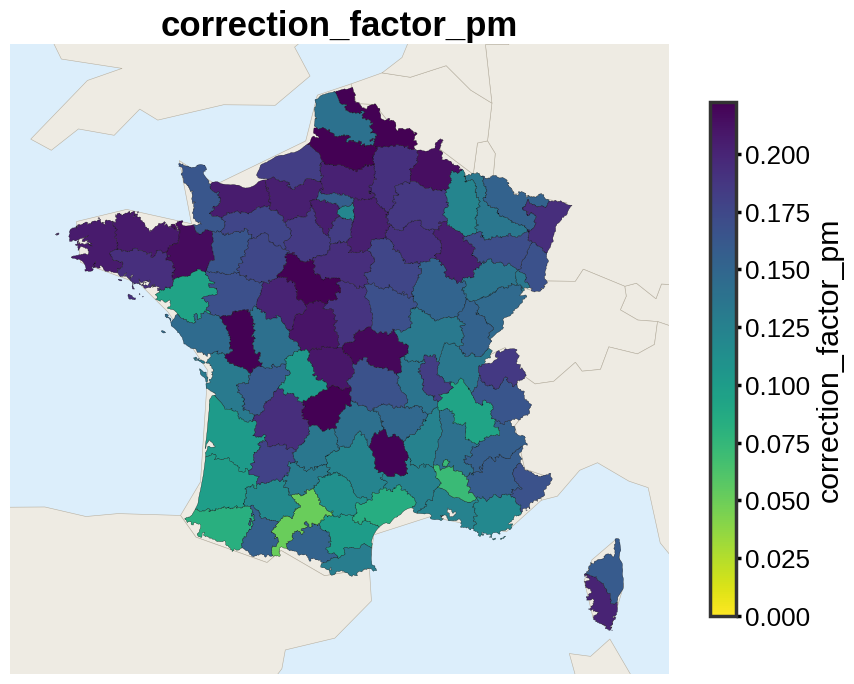

± median : 16.3% | corr(F1, ±) = -0.82


In [7]:
# Operational reading: the half-width of the interval on the corrected quantity
table['correction_factor_pm'] = table['correction_factor_rel_uncertainty'] / 2

fig_unc_map, _ = helpers.plot_metric_map(
    departements, table, 'correction_factor_pm',
    cmap=helpers.style.CMAP_SEQUENTIAL_BAD, vmin=0, vmax=table['correction_factor_pm'].quantile(0.95),
)
helpers.save_fig(fig_unc_map, f'{FIG_PREFIX}_correction_factor_uncertainty_map.png', FIGS_DIR)
plt.show()

print(f"± median : {table['correction_factor_pm'].median():.1%} | "
      f"corr(F1, ±) = {table['f1'].corr(table['correction_factor_pm']):.2f}")


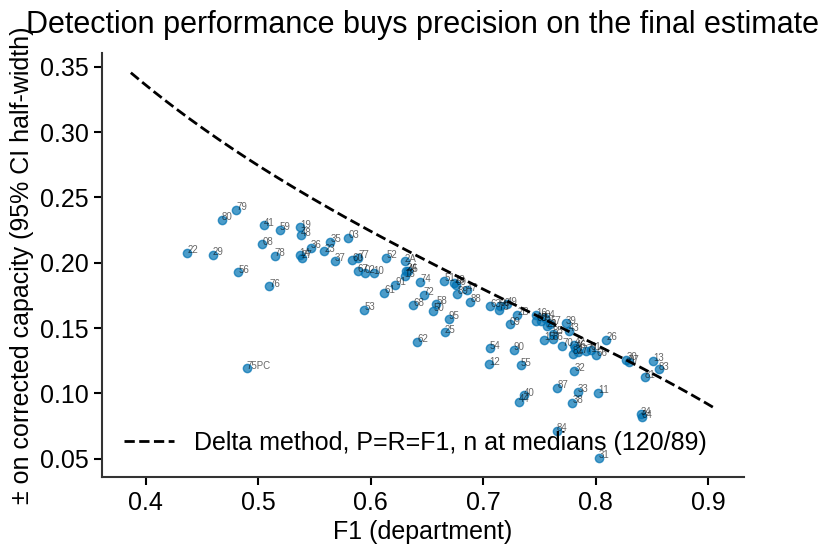

delta method vs Monte-Carlo : corr = 0.9993, ratio obs/pred median = 1.019
F1 in [0.00, 0.55) : 16 depts, ± median 20.9%
F1 in [0.55, 0.70) : 31 depts, ± median 18.5%
F1 in [0.70, 1.00) : 46 depts, ± median 13.3%


In [8]:
fig_scatter_f1, _ = helpers.plot_uncertainty_scatter(
    table, 'f1', 'correction_factor_pm',
    xlabel='F1 (department)',
    ylabel='± on corrected capacity (95% CI half-width)',
    title='Detection performance buys precision on the final estimate',
)

# --- Theoretical curve, zero free parameters: delta method on the ratio P/R ---
# CV(P/R)^2 = CV(P)^2 + CV(R)^2; for a Beta posterior, CV^2 = (1-m)/(m*(n_eff+1)).
# Guide curve under P = R = phi, so F1 = phi, with n at the sample medians:
#   ±(phi) = z * sqrt[ (1-phi)/phi * (1/n_P + 1/n_R) ]
# The exact validation, per unit with its own P, R and n, is printed below. The
# correlation between prediction and Monte-Carlo is about 0.999: this line is a
# formula, not a fit, which is why it has no free parameters to tune.

import numpy as np
from scipy.stats import norm as _norm

z = _norm.ppf(1 - (1 - CI_LEVEL) / 2)

ax = fig_scatter_f1.axes[0]

n_P, n_R = table['n_precision'].median(), table['n_recall'].median()
phi = np.linspace(
    max(0.2, table['f1'].min() - 0.05),
    min(0.99, table['f1'].max() + 0.05),
    200,
)
pm_theory = z * np.sqrt((1 - phi) / phi * (1 / n_P + 1 / n_R))

ax.plot(
    phi,
    pm_theory,
    ls='--',
    color='black',
    lw=2,
    label=f'Delta method, P=R=F1, n at medians ({n_P:.0f}/{n_R:.0f})'
)

# ---------- Formatting ----------
ax.set_title(ax.get_title(), fontsize=22, pad=15)
ax.set_xlabel(ax.get_xlabel(), fontsize=18)
ax.set_ylabel(ax.get_ylabel(), fontsize=18)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    width=1.5,
    length=6,
)

ax.legend(fontsize=18)

# Optional: thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

fig_scatter_f1.tight_layout()

helpers.save_fig(
    fig_scatter_f1,
    f'{FIG_PREFIX}_f1_vs_correction_factor_uncertainty_scatter.png',
    FIGS_DIR,
)

plt.show()


# --------------------------------------------------------------------------
# Exact per-unit validation: delta method against Monte-Carlo
# --------------------------------------------------------------------------

def _beta_stats(a, b):
    return a / (a + b), a * b / ((a + b) ** 2 * (a + b + 1))


mP, vP = _beta_stats(table['alpha_precision'], table['beta_precision'])
mR, vR = _beta_stats(table['alpha_recall'], table['beta_recall'])

pm_pred = z * np.sqrt(vP / mP**2 + vR / mR**2)

ok = pm_pred.notna() & table['correction_factor_pm'].notna()

print(
    f"delta method vs Monte-Carlo : "
    f"corr = {pm_pred[ok].corr(table.loc[ok, 'correction_factor_pm']):.4f}, "
    f"ratio obs/pred median = "
    f"{(table.loc[ok, 'correction_factor_pm'] / pm_pred[ok]).median():.3f}"
)

# The message, in numbers
for lo, hi in [(0, 0.55), (0.55, 0.7), (0.7, 1.0)]:
    m = (table['f1'] >= lo) & (table['f1'] < hi)
    if m.sum():
        print(
            f"F1 in [{lo:.2f}, {hi:.2f}) : "
            f"{m.sum():>2} depts, "
            f"± median {table.loc[m, 'correction_factor_pm'].median():.1%}"
        )

### 1.4 Units ranked by decreasing uncertainty

Every unit, worst first, on the correction factor. The two component uncertainties are shown
alongside so that the source can be read unit by unit: is it precision, recall, or both? It is
usually both, which is the point the previous section makes and this table demonstrates.

In [9]:
ranking_cols = ['dpt', 'n_precision', 'n_recall', 'precision', 'recall',
                'precision_rel_uncertainty', 'recall_rel_uncertainty', 'correction_factor_rel_uncertainty']

ranking = (
    table.dropna(subset=['correction_factor_rel_uncertainty'])
    [ranking_cols]
    .sort_values('correction_factor_rel_uncertainty', ascending=False)
    .reset_index(drop=True)
)

print(f"Correction factor, relative uncertainty over {len(ranking)} units: "
      f"min={ranking['correction_factor_rel_uncertainty'].min():.1%}, "
      f"mediane={ranking['correction_factor_rel_uncertainty'].median():.1%}, "
      f"max={ranking['correction_factor_rel_uncertainty'].max():.1%}")

ranking

Correction factor, relative uncertainty over 93 units: min=10.1%, mediane=32.6%, max=48.1%


,dpt,n_precision,n_recall,precision,recall,precision_rel_uncertainty,recall_rel_uncertainty,correction_factor_rel_uncertainty
0,79,234,85.852,0.833333,0.337791,0.113216,0.448832,0.481218
1,80,331,85.260,0.564955,0.398780,0.184983,0.408760,0.465785
2,41,225,78.736,0.608889,0.431823,0.203358,0.398121,0.457362
3,19,120,88.328,0.716667,0.430215,0.215580,0.385151,0.454200
4,59,236,79.464,0.775424,0.390114,0.134875,0.422882,0.450105
5,48,239,80.396,0.891213,0.385591,0.088480,0.424386,0.441741
6,03,120,76.940,0.800000,0.454900,0.173534,0.387314,0.437573
7,35,168,78.940,0.708333,0.468710,0.188033,0.376358,0.431409
8,08,229,97.124,0.567686,0.453029,0.219101,0.360333,0.428090
9,36,223,86.532,0.695067,0.450700,0.169609,0.375632,0.422470


### 1.5 National summary

Not the mean of the per-unit rates, which would bias the result as soon as sample sizes differ
across units, and they differ a great deal here. The counts are summed across units first, then one
posterior is taken on the total.

The mean and median of the per-unit values are reported alongside as descriptive summaries, not as
the national estimator. The median is the one to read when a few units behave atypically.

In [10]:
helpers.national_summary(table, ci=CI_LEVEL)

,metric,pooled_mean,pooled_ci_low,pooled_ci_high,pooled_rel_uncertainty,dept_mean,dept_median,n_depts,n_total
0,precision,0.766173,0.759966,0.772324,0.016129,0.818230,0.866667,93,18023
1,recall,0.612423,0.604174,0.620640,0.026887,0.585291,0.607277,93,13449


### 1.6 Propagation to a corrected quantity

A raw quantity taken from the detections is biased in two directions at once: inflated by false
positives, understated by the installations that were missed. The correction multiplies by
precision and divides by recall.

**This assumes homogeneity**, a uniform factor independent of installation size. It is not tested
in this section; section 1.9 tests it directly, and specification B of the robustness battery
bounds what a violation would cost.

The raw quantity is a known constant, so it cancels out of the *relative* uncertainty. The
correction factor carries all of it, whatever the absolute value, which is why the ranking below is
exactly the ranking of 1.4.

In [11]:
demo = ranking.copy()
demo['mw_corrige'] = EXAMPLE_MW * table.set_index('dpt').loc[demo['dpt'], 'correction_factor_mean'].values
demo['mw_ci_low'] = EXAMPLE_MW * table.set_index('dpt').loc[demo['dpt'], 'correction_factor_ci_low'].values
demo['mw_ci_high'] = EXAMPLE_MW * table.set_index('dpt').loc[demo['dpt'], 'correction_factor_ci_high'].values

demo['pm_pct'] = table.set_index('dpt').loc[demo['dpt'], 'correction_factor_pm'].values

print(f"Example: {EXAMPLE_MW} MW raw, corrected by precision/recall, by decreasing uncertainty")
print("(lecture metier : mw_corrige ± pm_pct)")
demo[['dpt', 'n_precision', 'n_recall', 'pm_pct', 'mw_corrige', 'mw_ci_low', 'mw_ci_high']]

Example: 1000 MW raw, corrected by precision/recall, by decreasing uncertainty
(lecture metier : mw_corrige ± pm_pct)


,dpt,n_precision,n_recall,pm_pct,mw_corrige,mw_ci_low,mw_ci_high
0,79,234,85.852,0.240609,2093.887324,1662.619912,2670.236758
1,80,331,85.260,0.232892,1280.165688,1023.013623,1619.295126
2,41,225,78.736,0.228681,1302.634987,1039.697615,1635.473633
3,19,120,88.328,0.227100,1540.878476,1235.479477,1935.345752
4,59,236,79.464,0.225052,1761.976841,1418.833080,2211.907430
5,48,239,80.396,0.220871,2035.983959,1649.580536,2548.958704
6,03,120,76.940,0.218787,1630.229587,1319.726352,2033.070958
7,35,168,78.940,0.215704,1422.347033,1152.482208,1766.095103
8,08,229,97.124,0.214045,1189.410129,962.393611,1471.568753
9,36,223,86.532,0.211235,1442.736848,1175.517123,1785.029981


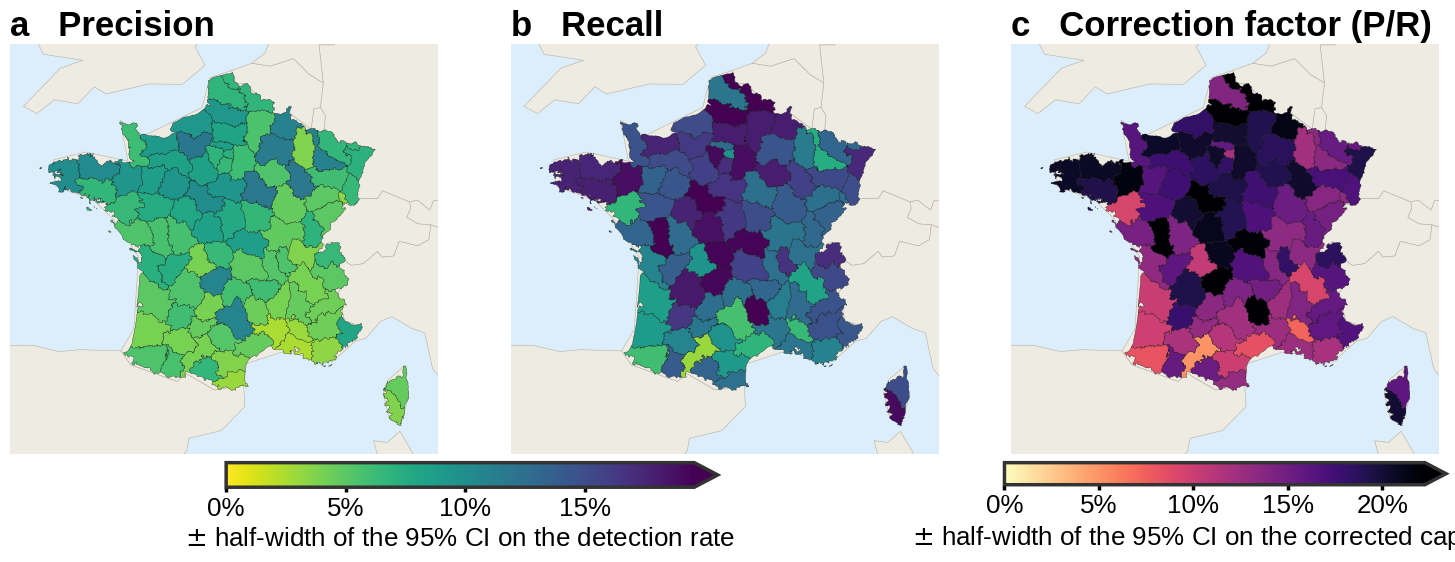

+/- precision    : mediane  6.1% | max 11.9% (27)
+/- rappel       : mediane 14.4% | max 22.4% (79)
+/- facteur P/R  : mediane 16.3% | max 24.1% (79)


In [12]:
# The three uncertainties side by side: on precision, on recall, and on the
# factor P/R.
# (a) and (b) SHARE a scale. They are two uncertainties on detection rates,
#     directly comparable, and a common scale is the only way to see which of
#     the two dominates in a given unit.
# (c) gets its own scale AND its own colormap. Its uncertainty is about a
#     corrected capacity, not a rate. The same colormap on a different scale
#     would invite exactly the false comparison this avoids.
fig_pm_row, _ = helpers.plot_halfwidth_maps(departements, table)
helpers.save_fig(fig_pm_row, f'{FIG_PREFIX}_halfwidth_maps.pdf', FIGS_DIR)
plt.show()

for col, name in [('precision_rel_uncertainty', 'precision'),
                  ('recall_rel_uncertainty', 'rappel'),
                  ('correction_factor_rel_uncertainty', 'facteur P/R')]:
    pm = table[col] / 2
    print(f"+/- {name:<12} : mediane {pm.median():5.1%} | max {pm.max():5.1%} "
          f"({table.loc[pm.idxmax(), 'dpt']})")

### 1.7 Annotation budgeting

For each unit, how many additional annotations would be needed, on precision alone, on recall
alone, or on both, to bring the correction factor's interval under a target. This is the tool that
sized the annotation campaigns, and it assumes new samples succeed at the current rate.

**Status: the campaign is closed.** The ±15% target is met in 31 of 96 units and the median sits at
±17%. Reaching ±15% everywhere would cost several thousand annotations for about two points of
narrative gain, and was not pursued. The residual uncertainty is reported as it stands, unit by
unit, rather than annotated away.

That choice is worth being explicit about: an audit that reported only the well-measured units
would look more precise and mean less.

**The cross ceiling.** Reinforcing one axis can never push the uncertainty below the other axis's
own uncertainty at its current sample size. When neither axis alone suffices, the both-axes column
gives the effort required, and it is the only option.

In [13]:
TARGET_REL_UNCERTAINTY = 0.30  # largeur totale IC95 <= 30% <=> estimation redressee a ±15%
                                # a planning tool, not a ceiling; see the markdown above

effort = helpers.samples_needed_for_target(table, target_rel_uncertainty=TARGET_REL_UNCERTAINTY, ci=CI_LEVEL)
print(f"{len(effort)} departements, cible = {TARGET_REL_UNCERTAINTY:.0%} d'incertitude relative")
effort

93 departements, cible = 30% d'incertitude relative


,dpt,current_rel_uncertainty,n_precision,n_recall,n_precision_add,n_recall_add,n_both_add,axe_prioritaire
0,79,0.481218,234,85.852,NaN,400,NaN,recall
1,80,0.465785,331,85.260,NaN,400,NaN,recall
2,41,0.457362,225,78.736,NaN,400,NaN,recall
3,19,0.454200,120,88.328,NaN,800,NaN,recall
4,59,0.450105,236,79.464,NaN,400,NaN,recall
5,48,0.441741,239,80.396,NaN,400,NaN,recall
6,03,0.437573,120,76.940,NaN,400,NaN,recall
7,35,0.431409,168,78.940,NaN,400,NaN,recall
8,08,0.428090,229,97.124,NaN,400,NaN,recall
9,36,0.422470,223,86.532,NaN,400,NaN,recall


### 1.8 A methodological check: Bayesian against frequentist

An independent verification, not a second set of numbers to interpret. A Wilson interval, which
uses no prior, is computed alongside the Bayesian interval used everywhere above. The largest
divergence across all units is printed below.

A small divergence is the signal that the Bayesian figures are not an artefact of the prior. A
large one would mean the prior is doing work the data does not support, which is exactly what one
would want to know.

In [14]:
check = helpers.add_frequentist_uncertainty(table, ci=CI_LEVEL)
diff_prec = (check['precision_rel_uncertainty'] - check['precision_wilson_rel_uncertainty']).abs()
diff_rec = (check['recall_rel_uncertainty'] - check['recall_wilson_rel_uncertainty']).abs()

print(f"Largest Bayesian vs Wilson divergence -- precision: {diff_prec.max():.1%}, recall: {diff_rec.max():.1%}")

Largest Bayesian vs Wilson divergence -- precision: 1.0%, recall: 12.0%


## 1.9 Size homogeneity: the assumption the whole correction rests on

The correction is valid only if detection performance does not depend systematically on
installation size. This section measures that **directly on the annotated samples**, independently
of the registries audited downstream, which is what makes it non-circular: nothing here uses the
quantity the audit is trying to establish.

**Size-weighted precision** is the share of *detected capacity* that is real, each annotated
detection weighted by its estimated size. This costs nothing extra, since every annotation is
already a detection polygon. If false positives were the same size as true ones, it would coincide
with the counted precision; any gap measures the homogeneity violation on that side.

**Size-weighted recall** is the share of *real capacity* captured, each ground-truth point weighted
by its estimated size. It is computable only on the subset of ground truth that carries a footprint,
and the reason is structural rather than practical: a *missed* system has no detected polygon, so
its size can only come from the ground truth itself. Points without a footprint are out of the
calculation.

**Both ratios are invariant to the conversion coefficient**, which appears in numerator and
denominator and cancels. These measures are therefore orthogonal to the conversion sensitivity, and
the two robustness axes probe genuinely different directions rather than the same one twice.

**What to expect, and why.** The weighted recall should be indistinguishable from the counted one:
small systems are missed more often but weigh little, and the two effects offset by construction.
The weighted precision should come out slightly lower, false positives being somewhat larger than
true ones. These columns feed specification B of the robustness battery; the paper's central factor
stays the counted P/R, whose binomial machinery is exact, and the weighted version bounds the size
effect rather than replacing it.

In [15]:
DETECTIONS_FILE = paths.DETECTIONS
RECALL_SRC_FILE = paths.RECALL_SRC
MIN_N_RECALL_KWP = 40   # below this, the weighted recall is too noisy and B falls back to counts

# Weighted precision: each annotated detection weighted by its estimated size
det_kwp = gpd.read_file(DETECTIONS_FILE, columns=['array_id', 'kWp'], ignore_geometry=True) \
    .set_index('array_id')['kWp']
pp_w = precision_points.copy()
pp_w['kWp'] = pp_w['array_id'].map(det_kwp)
pp_w = pp_w[pp_w['kWp'].notna()]
prec_w = pp_w.groupby('dpt').apply(
    lambda g: (g['pred'] * g['kWp']).sum() / g['kWp'].sum(), include_groups=False).rename('precision_kwp')

# Weighted recall: each sized ground-truth point weighted by its estimated size
recall_src = pd.read_csv(RECALL_SRC_FILE, dtype={'dept': str})
rp_w = recall_points.merge(recall_src[['point_id', 'kWp_est']], on='point_id', how='left')
rp_w = rp_w[rp_w['kWp_est'].notna()]
rec_w = rp_w.groupby('dpt').apply(
    lambda g: pd.Series({'recall_kwp': (g['pred'] * g['kWp_est']).sum() / g['kWp_est'].sum(),
                          'n_recall_kwp': len(g)}), include_groups=False)

table = table.merge(prec_w, on='dpt', how='left').merge(rec_w, on='dpt', how='left')

p_nat_c = precision_points['pred'].mean()
p_nat_w = (pp_w['pred'] * pp_w['kWp']).sum() / pp_w['kWp'].sum()
r_nat_c = rp_w['pred'].mean()
r_nat_w = (rp_w['pred'] * rp_w['kWp_est']).sum() / rp_w['kWp_est'].sum()
print(f"precision: counted {p_nat_c:.3f} | size-weighted {p_nat_w:.3f}  (delta {p_nat_w - p_nat_c:+.3f})")
print(f"recall   : counted {r_nat_c:.3f} | size-weighted {r_nat_w:.3f}  (delta {r_nat_w - r_nat_c:+.3f})"
      f"   [sized subset: {len(rp_w)} points]")
print(f"units with fewer than {MIN_N_RECALL_KWP} sized recall points, falling back under B: "
      f"{(table['n_recall_kwp'].fillna(0) < MIN_N_RECALL_KWP).sum()}")
print(f"\nVerdict homogeneite : recall OK (delta ~0), precision violation moderee "
      f"({p_nat_w - p_nat_c:+.1%}) -> bounded by specification B of the battery.")


precision: counted 0.766 | size-weighted 0.733  (delta -0.033)
recall   : counted 0.645 | size-weighted 0.649  (delta +0.004)   [sized subset: 8217 points]
units with fewer than 40 sized recall points, falling back under B: 59

Verdict homogeneite : recall OK (delta ~0), precision violation moderee (-3.3%) -> bounded by specification B of the battery.


## Part 2: the calibration table

One row per unit: raw counts, point estimates, Beta parameters, and the correction factor with its
relative uncertainty. Everything displayed above, and more, is in this file. It is the interface
between the evaluation and everything downstream, which is why the prior chosen here propagates
automatically rather than being re-declared anywhere else.

In [16]:
table.to_csv(OUTPUT_TABLE, index=False)
print(f"Ecrit : {BASE / OUTPUT_TABLE} ({len(table)} departements)")
table.head()

Ecrit : /tmp/nbdata/intermediate/evaluation/table.csv (93 departements)


,dpt,n_precision,tp_precision,fp_precision,precision,n_recall,tp_recall,fn_recall,recall,f1,...,f1_ci_high,f1_rel_uncertainty,correction_factor_mean,correction_factor_ci_low,correction_factor_ci_high,correction_factor_rel_uncertainty,correction_factor_pm,precision_kwp,recall_kwp,n_recall_kwp
0,01,120,116,4,0.966667,100.620,68.0,32.620,0.675810,0.795485,...,0.837270,0.151926,1.447114,1.277749,1.663156,0.266329,0.133164,0.968414,0.038505,6.0
1,02,437,322,115,0.736842,78.144,39.0,39.144,0.499079,0.595090,...,0.676771,0.214862,1.407721,1.171826,1.712676,0.384202,0.192101,0.667744,0.662555,11.0
2,03,120,96,24,0.800000,76.940,35.0,41.940,0.454900,0.579998,...,0.681677,0.250445,1.630230,1.319726,2.033071,0.437573,0.218787,0.753322,0.562903,21.0
3,04,120,114,6,0.950000,79.824,50.0,29.824,0.626378,0.754970,...,0.812110,0.182686,1.516389,1.308057,1.785770,0.315034,0.157517,0.965658,0.700740,29.0
4,05,120,114,6,0.950000,83.688,52.0,31.688,0.621356,0.751310,...,0.808900,0.181486,1.526768,1.315928,1.791353,0.311393,0.155696,0.948451,0.732368,26.0


## Part 3: descriptive statistics

How many points, where they come from, and what they look like on the ground. The annotation effort
is closed, so this documents the final sample rather than planning the next one.

### 3.1 Annotated points per unit

In [17]:
summary = helpers.points_summary(table)
summary

,metric,n_total,n_depts,n_min,n_median,n_mean,n_max
0,precision,18023,93,120,120.000,193.795699,808
1,recall,13449,93,76,88.804,144.620172,1878


In [18]:
points_by_dept = table[['dpt', 'n_precision', 'n_recall']].sort_values('dpt').reset_index(drop=True)
points_by_dept

,dpt,n_precision,n_recall
0,01,120,100.620
1,02,437,78.144
2,03,120,76.940
3,04,120,79.824
4,05,120,83.688
5,06,120,85.688
6,07,120,97.096
7,08,229,97.124
8,09,120,107.008
9,10,235,89.532


### 3.2 One unit, illustrated

Only meaningful at this scale: nationally the point density resolves into nothing readable, which
is what the aggregated maps of section 1.2 are for. Precision points, the model's detections, beside
recall points, the ground truth, with the unit outline behind.

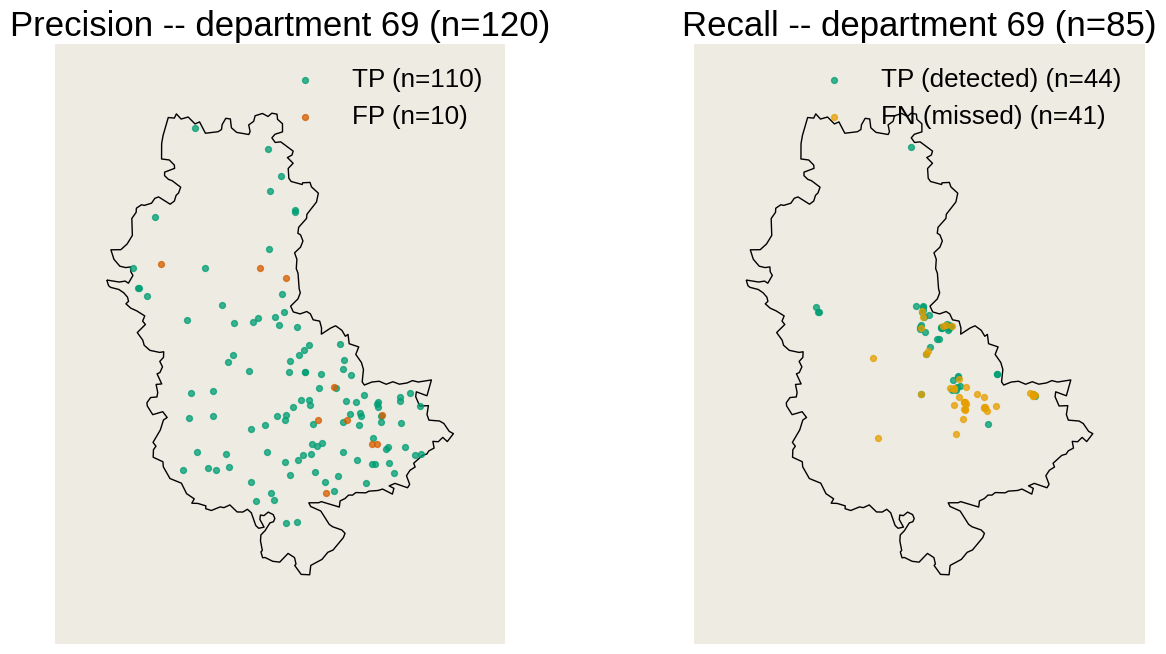

In [19]:
EXAMPLE_DEPT = '69'  # change to illustrate another unit

fig_dept, _ = helpers.plot_department_points(EXAMPLE_DEPT, precision_points, recall_points, departements)
helpers.save_fig(fig_dept, f'{FIG_PREFIX}_department_points_{EXAMPLE_DEPT}.png', FIGS_DIR)
plt.show()

/sessions/happy-gracious-franklin/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/sessions/happy-gracious-franklin/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/sessions/happy-gracious-franklin/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/sessions/happy-gracious-franklin/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.z

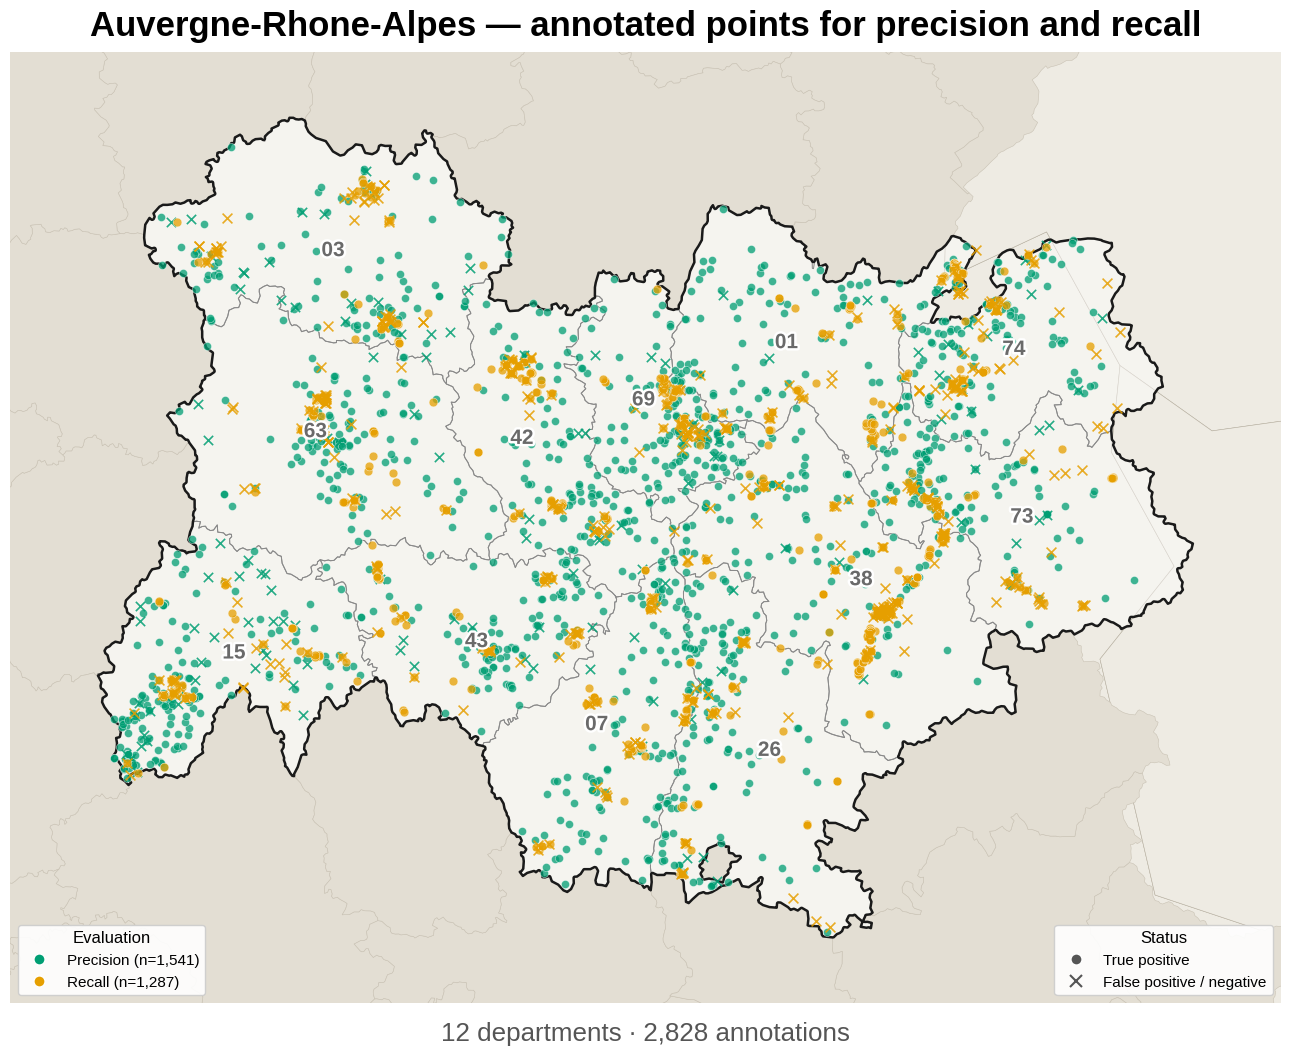

In [20]:
REGION = "Auvergne-Rhone-Alpes"

fig_region, _ = helpers.plot_region_points(
    REGION,
    precision_points,
    recall_points,
    departements,
)

helpers.save_fig(
    fig_region,
    f"{FIG_PREFIX}_region_points_{REGION}.png",
    FIGS_DIR,
)

plt.show()

### 3.3 Recall by ground-truth source

The recall sample draws on two origins: installations already mapped in OpenStreetMap, and points
annotated by hand across a wider spread. Does recall differ with the origin?

The question is not idle. If it did, the mix of sources in a unit would leak into its correction
factor, and units annotated mostly from one source would be systematically mis-corrected.

Two readings: pooled by source nationally, one figure each with an interval; and per unit and
source, to see whether any national gap is uniform or driven by a handful of units. The formal test
at constant composition is in `quality_assessment/gt_bias_tests.ipynb`.

In [21]:
recall_national_by_source, recall_by_dept_source = helpers.recall_by_source(recall_points, ci=CI_LEVEL)
recall_national_by_source

,source,n,tp,fn,recall_mean,recall_ci_low,recall_ci_high,recall_rel_uncertainty
0,OSM,8441,5338,3103,0.632374,0.622060,0.642629,0.032526
1,manual_annotation,5389,2899,2490,0.537941,0.524619,0.551235,0.049478


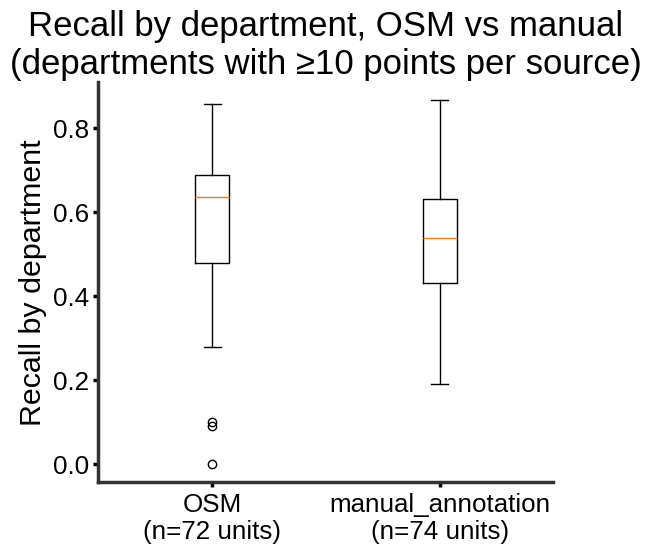

In [22]:
fig_source_box, _ = helpers.plot_recall_by_source_boxplot(recall_by_dept_source, min_n=10)
helpers.save_fig(fig_source_box, f'{FIG_PREFIX}_recall_osm_vs_manual_boxplot.png', FIGS_DIR)
plt.show()

In [23]:
lo, hi = recall_national_by_source.set_index('source')[['recall_ci_low', 'recall_ci_high']].values.T
overlap = lo.max() <= hi.min()
print(f"{CI_LEVEL:.0%} intervals, OSM vs manual: {'overlap' if overlap else 'do NOT overlap'} "
      f"-- {'no difference detected' if overlap else 'a difference is likely'} "
      f"at this level.")

95% intervals, OSM vs manual: do NOT overlap -- a difference is likely at this level.


## Part 4: does the imagery vintage matter?

Do precision and recall vary with the year the imagery was taken, through sensor quality, exposure
or resolution?

This is a different question from the temporal alignment used to compare against the registry. That
one aligns dates to know whether an installation *existed* when the photograph was taken. This one
asks whether the model *detects equally well* depending on the year of the photograph, independently
of what is visible in it. The two are easy to conflate and answer different things.

**The difficulty.** Units sharing a vintage are sometimes geographically contiguous, campaigns being
flown zone by zone, so a gap between years can be terrain or urbanisation wearing a vintage costume.
Section 4.2 tests whether the gap of 4.1 survives that confounding.

In [24]:
DATES_FILE = Path(paths.IMAGERY_DATES)

assert DATES_FILE.exists(), (
    f"{DATES_FILE} introuvable -- lancer postprocess/dates/datation.py d'abord "
    f"(cd ../../postprocess/dates && python datation.py)"
)

dept_year = helpers.load_dept_year_mapping(DATES_FILE)
print(f"{len(dept_year)} departements, annees representees : {sorted(dept_year['year'].unique())}")
dept_year['year'].value_counts().sort_index()

96 departements, annees representees : [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


year
2022     1
2023    27
2024    35
2025    33
Name: count, dtype: int64

### 4.1 Pooled precision and recall by vintage

In [25]:
by_year = helpers.precision_recall_by_year(precision_points, recall_points, dept_year, ci=CI_LEVEL)
by_year

,year,metric,n,tp,fail,mean,ci_low,ci_high,rel_uncertainty
0,2022,precision,120,86,34,0.714876,0.631594,0.791431,0.223588
1,2023,precision,4821,3811,1010,0.790440,0.778840,0.801811,0.029061
2,2024,precision,6121,4808,1313,0.785446,0.775076,0.795639,0.026181
3,2025,precision,6153,4713,1440,0.765925,0.755265,0.776420,0.027620
4,2022,recall,496,337,159,0.679074,0.637413,0.719371,0.120692
5,2023,recall,2491,1434,1057,0.575642,0.556185,0.594984,0.067401
6,2024,recall,4668,2747,1921,0.588456,0.574306,0.602533,0.047968
7,2025,recall,5774,3527,2247,0.610823,0.598213,0.623359,0.041168


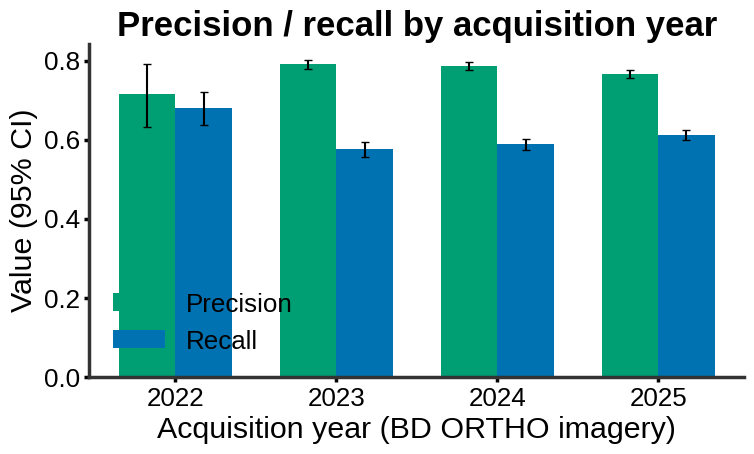

In [26]:
fig_year, _ = helpers.plot_precision_recall_by_year_barplot(by_year)
helpers.save_fig(fig_year, f'{FIG_PREFIX}_precision_recall_by_year.png', FIGS_DIR)
plt.show()

### 4.2 Disentangling vintage from geography

Each vintage is represented by a random handful of units, redrawn many times. If the gap of 4.1
survives when a different handful stands for each year on every draw, it is not reducible to one
geographic cluster.

**How to read the result, in both directions.** If the boxes overlap heavily from one year to the
next, the dispersion due to the choice of units is of the same order as the gap itself, and the
vintage effect is not demonstrated.

That is not the same as being ruled out. Wide dispersion proves an absence of power, not an absence
of effect, and the distinction is worth holding: a test that cannot detect an effect says nothing
about whether one exists.

One caveat to carry into the reading: a vintage represented by only two units in the whole dataset
has almost no sampling variability of its own, and its box is narrow for a reason unrelated to what
is being tested.

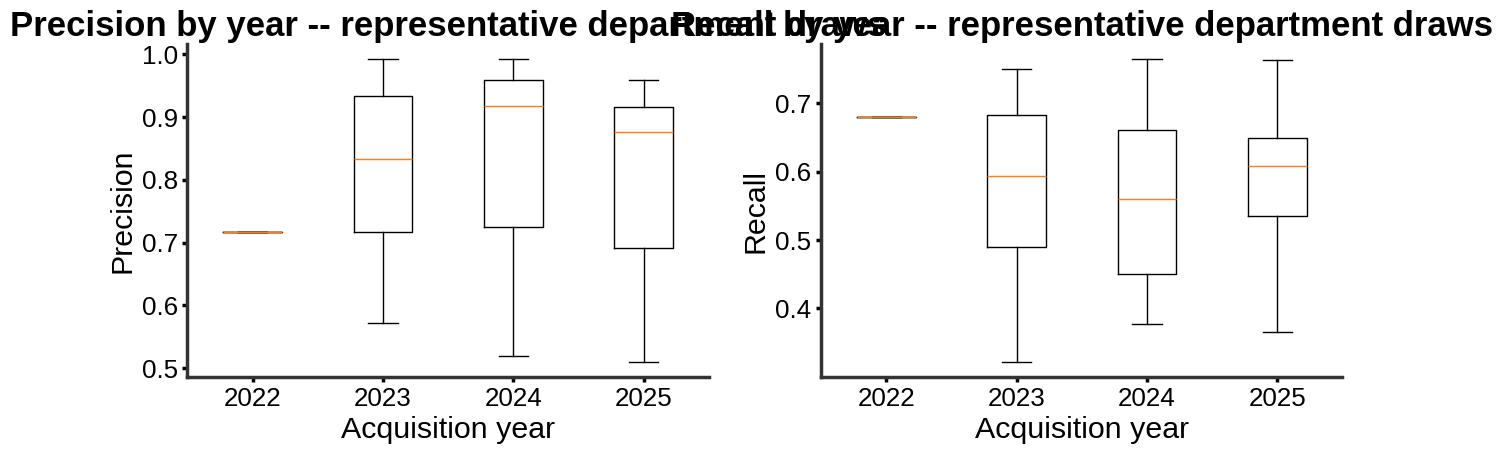

In [27]:
DEPTS_PER_YEAR = 1  # raise to 2 to check how sensitive the result is to this choice
N_DRAWS = 1000
SEED_YEAR = 42

draws = helpers.bootstrap_year_effect_by_department_draw(
    precision_points, recall_points, dept_year,
    depts_per_year=DEPTS_PER_YEAR, n_draws=N_DRAWS, seed=SEED_YEAR,
)

fig_draws, axes = plt.subplots(1, 2, figsize=(13, 5))
helpers.plot_year_effect_draws_boxplot(draws, metric='precision', ax=axes[0])
helpers.plot_year_effect_draws_boxplot(draws, metric='recall', ax=axes[1])
plt.tight_layout()
helpers.save_fig(fig_draws, f'{FIG_PREFIX}_year_effect_department_draws.png', FIGS_DIR)
plt.show()